## Precip maps for ERA5 and CESM2
### Seasonal and annual average: Figs 2,11,12
NB reads in all of CESM2 LENS data for 2015-2023 so takes a while

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import glob
from matplotlib import rcParams

In [2]:
rcParams['font.size'] = 20
#file locs
file_loc_1 = '/div/no-backup-nac/reanalysis/ERA-5/day/regridded_to_CESM2LENS'
land_mask_fileloc = '/div/nac/users/zofias/CESM_output/land_mask/Norway_mask_192_288_CESM2-LENS.nc'

file_loc_2 = '/div/no-backup/Large_Ensemble_data/CESM2-LENS/BSSP370smbb/PRECT'
filelist_cesm2lens = sorted(glob.glob(f'{file_loc_2}/*h1*.nc'))

In [3]:
#selects lat lon bounds for region for plotting
#regions = {'SA': [5,35,65,95],'EA' : [20,53,95,133],'NA' : [25,70,-150,-45], 'EU' : [35,70,-20,45],'NO' : [53,72,0,32],'NO_ext': [50,80,-30,37]}

lat_min, lat_max, lon_min, lon_max = [53,72,0,32]

In [4]:
#read in data, select only overlap period between ERA5 adn CESM2LENS (SSP370)
era5_data = xr.open_dataset(f'{file_loc_1}/precipTOT_day_ERA5_19400102-20221231_CESMLENSgrid.nc').sel(time=slice('2015-01-01','2023-01-01'))

#land mask
land_percent_data = xr.open_dataset(land_mask_fileloc)
land_percent_data = land_percent_data.assign_coords(lon=(((land_percent_data.lon + 180) % 360) - 180)).sortby('lon')
land_mask = land_percent_data.mask

#CESM2LENS data
# **** this reads in all ensemble members so the plots take ages, change to filelist_cesm2lens[:5] for testing ****
cesm2_data = xr.open_mfdataset(filelist_cesm2lens, decode_times=True, combine="nested", concat_dim="member",data_vars=['PRECT']).sel(time=slice('2015-01-01','2023-01-01'))

In [5]:
#processing for CESM2LENS data
cesm2_data = cesm2_data.assign_coords(lon=(((cesm2_data.lon + 180) % 360) - 180)).sortby('lon')
cesm2_data = cesm2_data.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

cesm2_data['PRECT'] = cesm2_data['PRECT']*8.64e7
cesm2_data["PRECT"] = cesm2_data.PRECT.assign_attrs(units='mm/day')

In [6]:
#units are in m (daily), convert to mm/day
era5_data['tp'] = era5_data['tp'] * 1000
era5_data["tp"] = era5_data.tp.assign_attrs(long_name = "Total precipitation", units='mm/day',cell_methods = "time: sum")

In [7]:
era5_data

<xarray.Dataset>
Dimensions:    (time: 2922, bnds: 2, lon: 288, lat: 192)
Coordinates:
  * time       (time) datetime64[ns] 2015-01-01T11:00:00 ... 2022-12-31T11:00:00
  * lon        (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    tp         (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.3142 0.3146 0.3146
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Mar 13 15:56:27 2026: cdo remapcon,prect_CESMLENS_grid....
    frequency:    day
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [8]:
#mask array, anything not land has data = nan
era5_data['PRECT_land'] = era5_data['tp'].where(land_mask)
cesm2_data['PRECT_land'] = cesm2_data['PRECT'].where(land_mask)

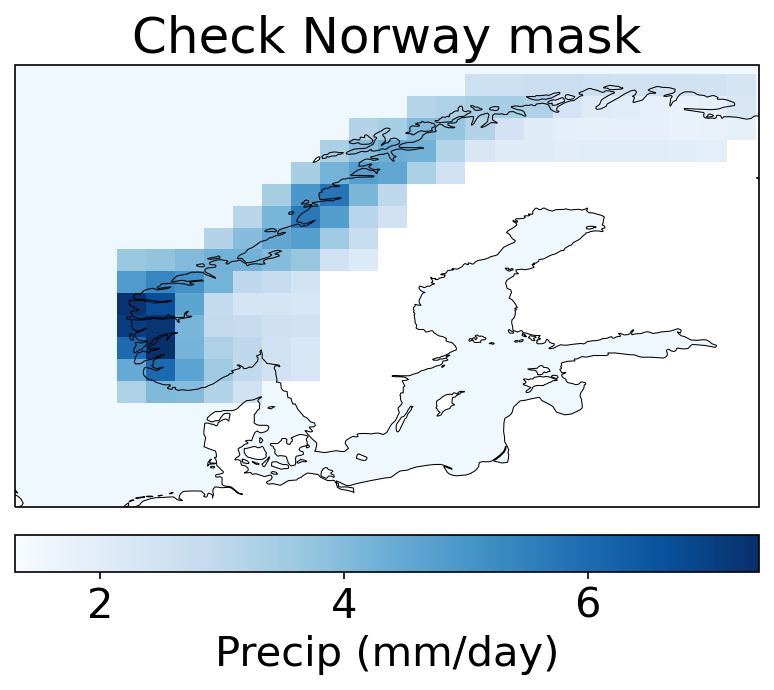

In [9]:
#Check land mask on map plot
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = era5_data['PRECT_land'].mean(dim='time').plot(cmap='Blues',
    cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(lon_min,lon_max),
    ylim=(lat_min,lat_max),
    )

plt.title(f"Check Norway mask")
axis.coastlines(linewidth=0.5)  # cartopy function
axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

## Seasonal calculations and plots

In [10]:
era5_seasonal = era5_data.PRECT_land.groupby("time.season").mean('time')
era5_monthly = era5_data.PRECT_land.groupby("time.month").mean('time')


cesm2_seasonal = cesm2_data.PRECT_land.mean(dim='member').groupby("time.season").mean('time')
cesm2_monthly = cesm2_data.PRECT_land.mean(dim='member').groupby("time.month").mean('time')

In [11]:
seasons_ordered = ['MAM', 'JJA', 'SON', 'DJF']

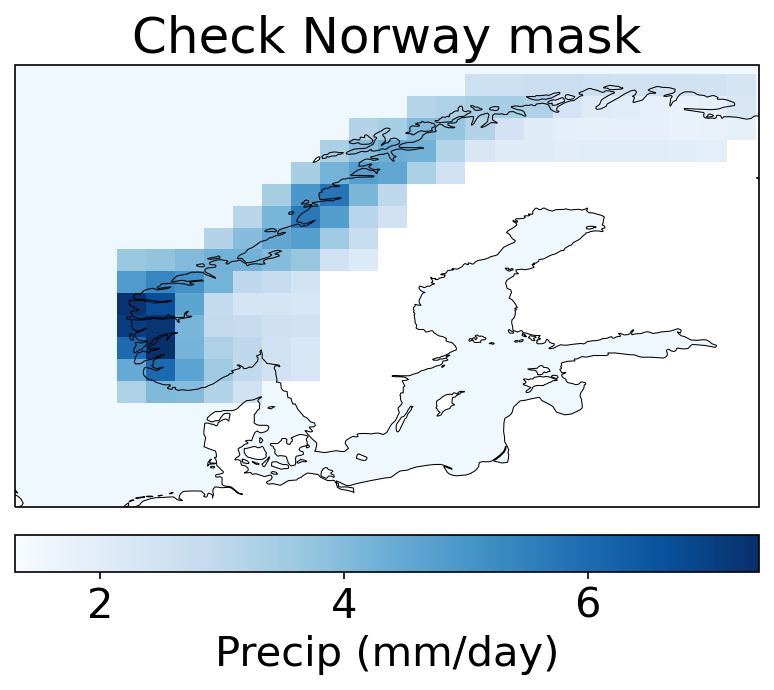

In [12]:
#Check land mask on map plot
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = era5_data['PRECT_land'].mean(dim='time').plot(cmap='Blues',
    cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(lon_min,lon_max),
    ylim=(lat_min,lat_max),
    )

plt.title(f"Check Norway mask")
axis.coastlines(linewidth=0.5)  # cartopy function
axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

Text(0.5, 1.08, 'ERA5 2015-2023')

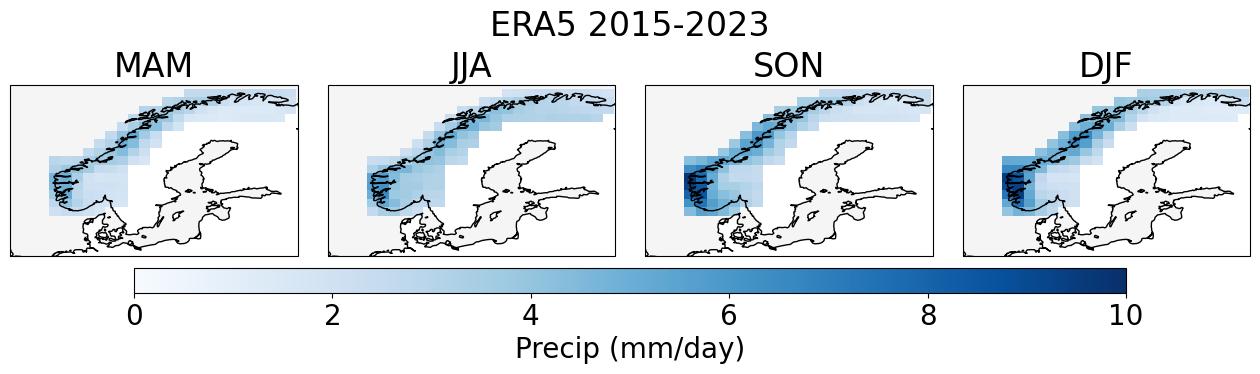

In [13]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =era5_seasonal.sel(season=seasons_ordered).plot(cmap='Blues',
                       vmin=0,vmax=10,
                       col='season',
                       cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('ERA5 2015-2023',y=1.08)#,fontsize=26)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

Text(0.5, 1.08, 'CESM2-LENS 2015-2023')

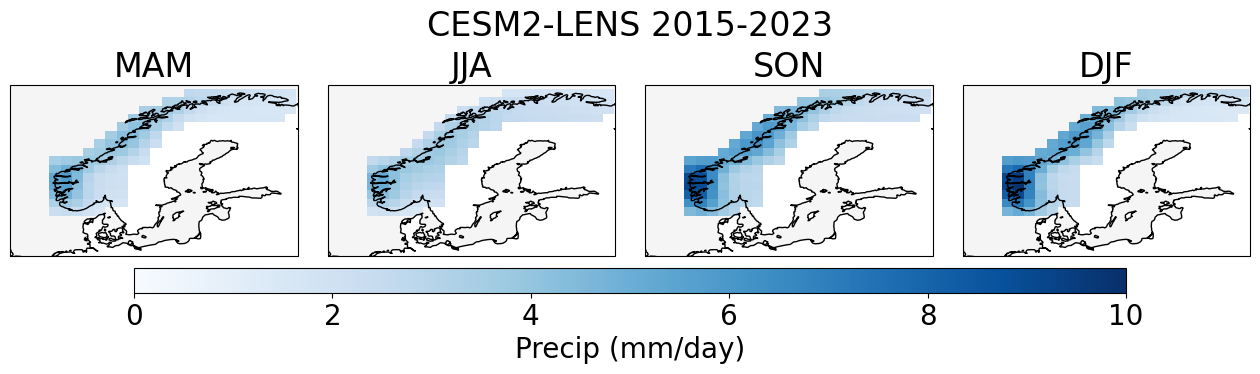

In [14]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =cesm2_seasonal.sel(season=seasons_ordered).plot(cmap='Blues',
                       vmin=0,vmax=10,
                       col='season',
                       cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('CESM2-LENS 2015-2023',y=1.08)#,fontsize=26)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

Text(0.5, 0.98, 'ERA5 monthly precip means')

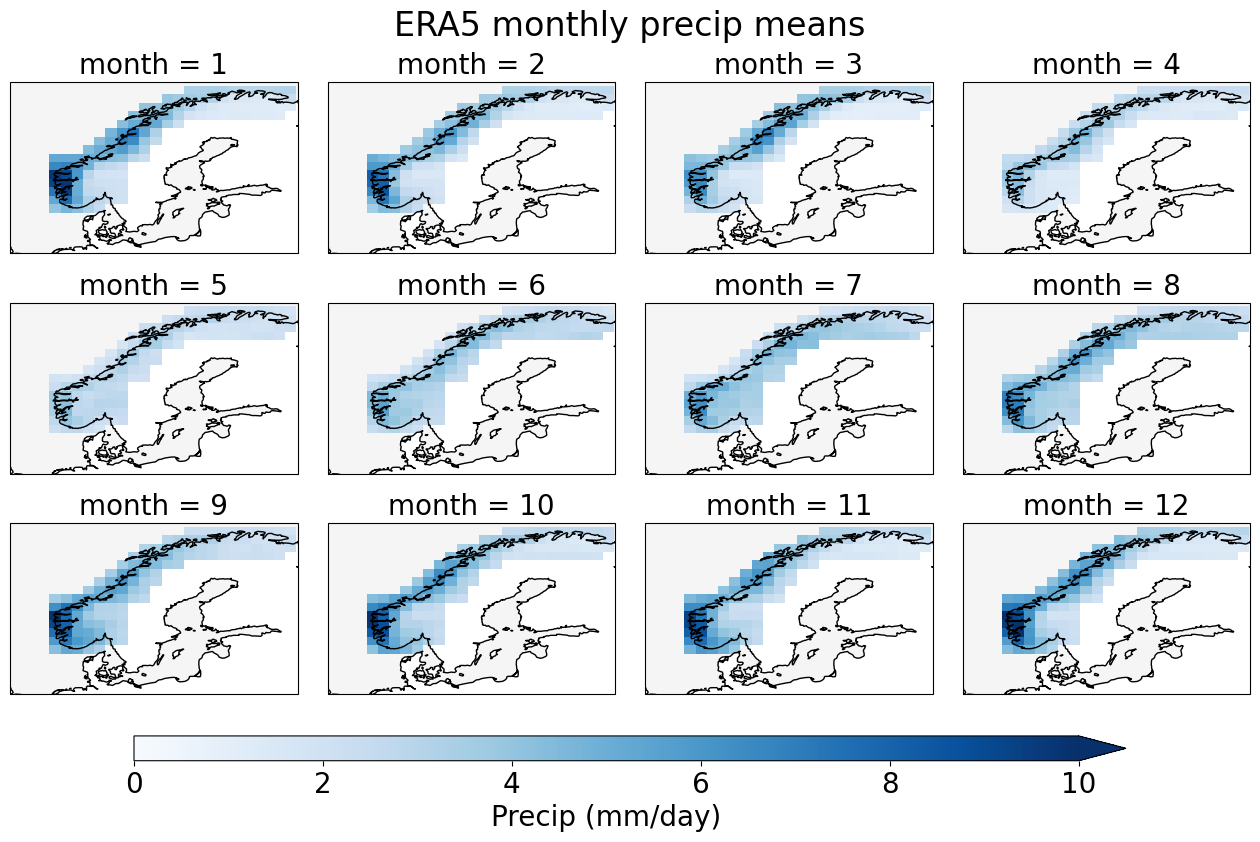

In [15]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =era5_monthly.plot(cmap='Blues',
                       vmin=0,vmax=10,
                       col='month',
                       col_wrap=4,
                       cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))


fg.fig.suptitle('ERA5 monthly precip means')#,y=0.87,fontsize=26)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

In [16]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =cesm2_monthly.plot(cmap='Blues',
                       vmin=0,vmax=10,
                       col='month',
                       col_wrap=4,
                       cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))


fg.fig.suptitle('CESM2 monthly precip means')#,y=0.87,fontsize=26)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

KeyboardInterrupt: 

## Bias plots

In [17]:
bias_seasonal = cesm2_seasonal - era5_seasonal
bias_monthly = cesm2_monthly - era5_monthly

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =bias_seasonal.sel(season=seasons_ordered).plot(cmap='BrBG',
                       vmin=-4,vmax=4,
                       col='season',
                       cbar_kwargs={'label': f'Precip difference (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('CESM2LENS - ERA5, 2015-2023',y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

Text(0.5, 0.98, 'Monthly precip means bias 2015-2023 (CESM2LENS - ERA5)')

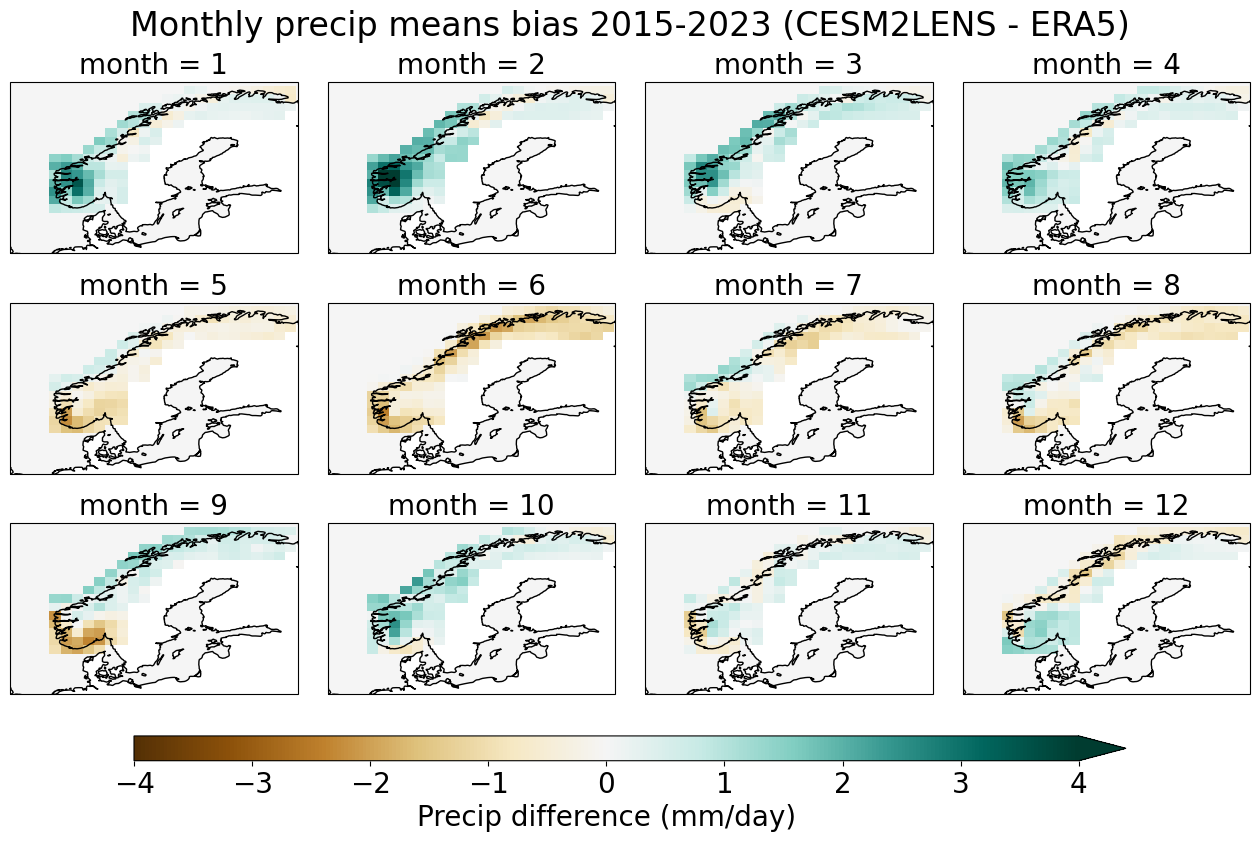

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =bias_monthly.plot(cmap='BrBG',
                       vmin=-4,vmax=4,
                       col='month',
                       col_wrap=4,
                       cbar_kwargs={'label': f'Precip difference (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       ) 

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))

fg.fig.suptitle('Monthly precip means bias 2015-2023 (CESM2LENS - ERA5)')#,y=0.87,fontsize=26)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

## Calculate percentiles and plot

In [ ]:
era5_data['PRECT_90'] = era5_data['PRECT_land'].quantile(0.9,dim=('time'))
era5_data['PRECT_99'] = era5_data['PRECT_land'].quantile(0.9,dim=('time'))

era5_90seasonal = era5_data['PRECT_land'].groupby("time.season").quantile(0.9,dim='time')
era5_99seasonal = era5_data['PRECT_land'].groupby("time.season").quantile(0.99,dim='time')

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [ ]:
cesm2_90seasonal = cesm2_data['PRECT_land'].chunk(dict(member=-1)).groupby("time.season").quantile(0.9,dim=('time','member'))
cesm2_99seasonal = cesm2_data['PRECT_land'].chunk(dict(member=-1)).groupby("time.season").quantile(0.99,dim=('time','member'))

In [ ]:
bias_99_seasonal = cesm2_99seasonal - era5_99seasonal
bias_90_seasonal = cesm2_90seasonal - era5_90seasonal

In [ ]:
cesm2_90seasonal

<xarray.DataArray 'PRECT_land' (season: 4, lat: 20, lon: 26)>
dask.array<concatenate, shape=(4, 20, 26), dtype=float64, chunksize=(1, 20, 26), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float64 53.25 54.19 55.13 56.07 ... 68.32 69.27 70.21 71.15
  * lon       (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 27.5 28.75 30.0 31.25
    quantile  float64 0.9
  * season    (season) object 'DJF' 'JJA' 'MAM' 'SON'

Text(0.5, 1.08, 'ERA5 90th percentile')

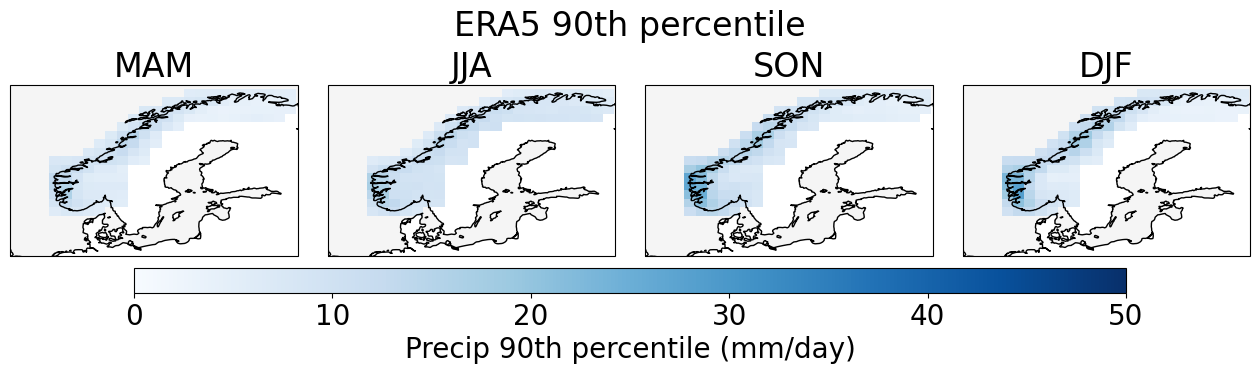

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =era5_90seasonal.sel(season=seasons_ordered).plot(cmap='Blues',
                       vmin=0,vmax=50,
                       col='season',
                       cbar_kwargs={'label': f'Precip 90th percentile (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)
    
fg.fig.suptitle('ERA5 90th percentile',y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


Text(0.5, 1.08, 'CESM2 90th percentile')

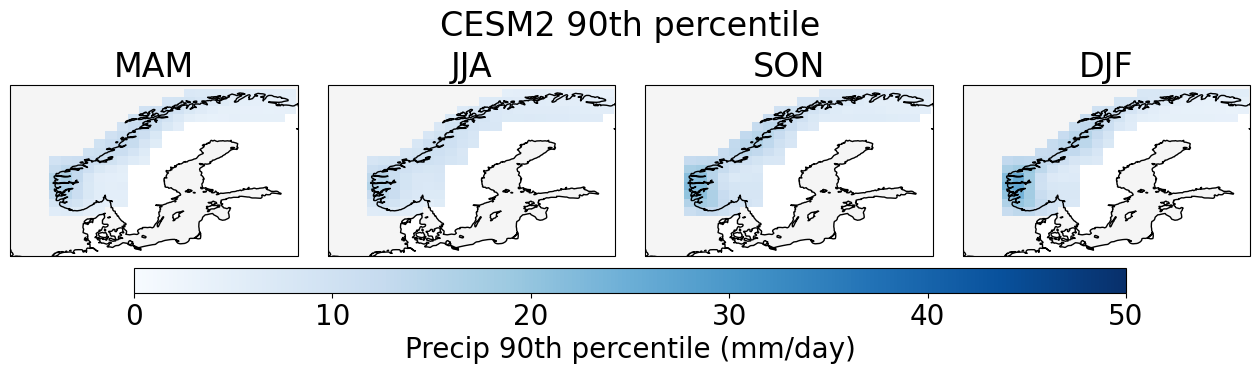

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =cesm2_90seasonal.sel(season=seasons_ordered).plot(cmap='Blues',
                       vmin=0,vmax=50,
                       col='season',
                       cbar_kwargs={'label': f'Precip 90th percentile (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)
    
fg.fig.suptitle('CESM2 90th percentile',y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

Text(0.5, 1.08, 'ERA5 99th percentile')

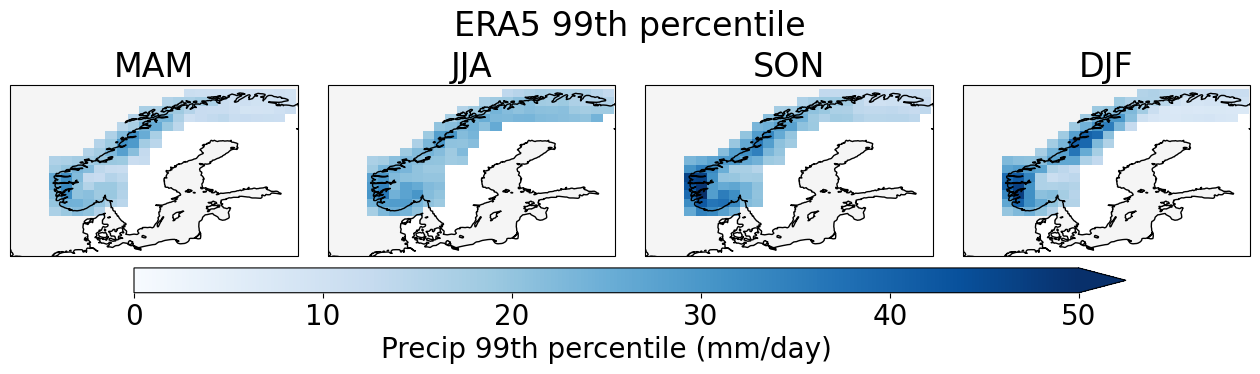

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =era5_99seasonal.sel(season=seasons_ordered).plot(cmap='Blues',
                       vmin=0,vmax=50,
                       col='season',
                       cbar_kwargs={'label': f'Precip 99th percentile (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('ERA5 99th percentile',y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


Text(0.5, 1.08, 'CESM2 99th percentile')

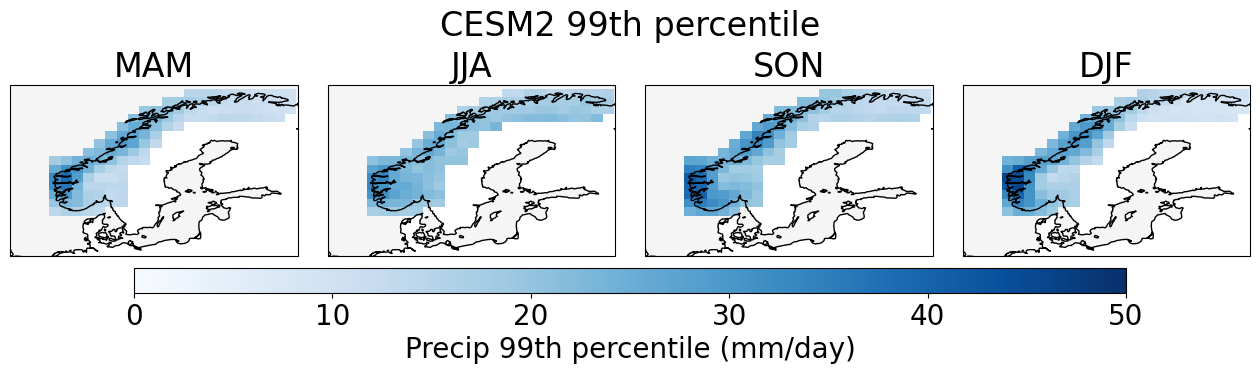

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =cesm2_99seasonal.sel(season=seasons_ordered).plot(cmap='Blues',
                       vmin=0,vmax=50,
                       col='season',
                       cbar_kwargs={'label': f'Precip 99th percentile (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('CESM2 99th percentile',y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


Text(0.5, 1.08, 'CESM2LENS - ERA5 90th percentile 2015-2023')

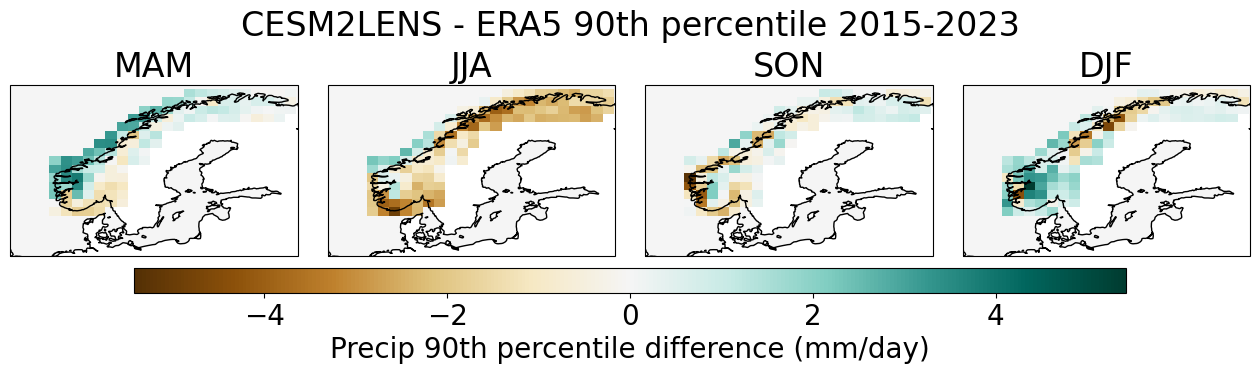

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =bias_90_seasonal.sel(season=seasons_ordered).plot(cmap='BrBG',
                       #vmin=-5,vmax=5,
                       col='season',
                       cbar_kwargs={'label': f'Precip 90th percentile difference (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('CESM2LENS - ERA5 90th percentile 2015-2023',y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


Text(0.5, 1.08, 'CESM2LENS - ERA5 99th percentile 2015-2023')

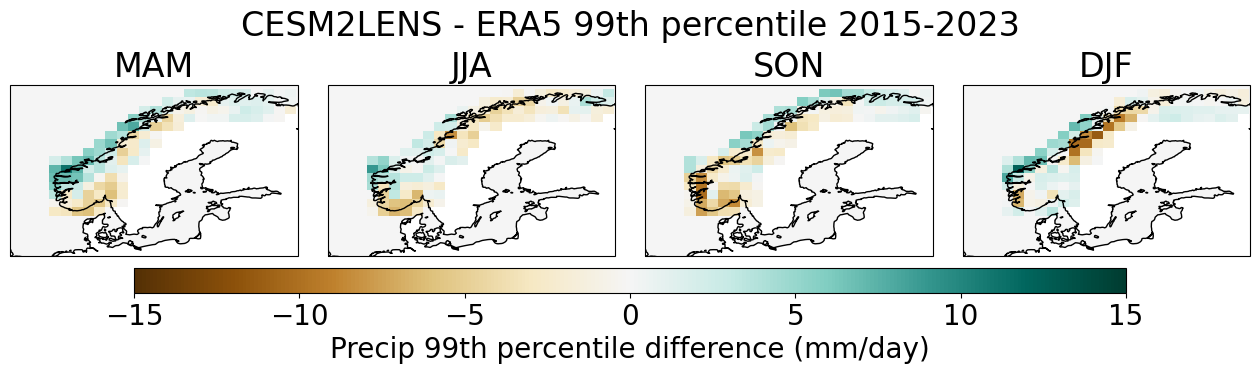

In [ ]:
#Check land mask on map plot
#fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg =bias_99_seasonal.sel(season=seasons_ordered).plot(cmap='BrBG',
                       vmin=-15,vmax=15,
                       col='season',
                       cbar_kwargs={'label': f'Precip 99th percentile difference (mm/day)','orientation':'horizontal','pad':0.05,"aspect": 40,"shrink": 0.8},
                       subplot_kws={"projection": ccrs.PlateCarree()},
                       xlim=(lon_min,lon_max),
                       ylim=(lat_min,lat_max),
                       )

fg.map(lambda: plt.gca().coastlines())
fg.map(lambda: plt.gca().add_feature(cartopy.feature.OCEAN,facecolor=("whitesmoke")))
for ax, title in zip(fg.axs.flat, seasons_ordered):
    ax.set_title(title)

fg.fig.suptitle('CESM2LENS - ERA5 99th percentile 2015-2023', y=1.08)
#plt.title(f"Check Norway mask")
#axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))